Quick analysis to compare the abundance of Fcy1p to that of other enzymes

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['savefig.dpi'] = 600
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11

In [5]:
# Importing S. cerevisiae protein abundances from PaxDB
pax_table = pd.read_table("Data_for_reviews/Scerevisiae_Whole_organism_(Integrated)_PaxDB.tsv")
pax_table['string_external_id'] = pax_table['string_external_id'].apply(lambda x: x.split('.')[1])
pax_table = pax_table.rename(columns={'string_external_id': 'orf_name'})  # For merging

In [6]:
# Importing the list of genes included in the most recent yeast metabolic network
# (from yeast9 GEM)
enzymes_all = pd.read_csv("Data_for_reviews/yeast9-GEM_genes.csv")
enzymes_all['SHORT NAME'] = enzymes_all['SHORT NAME'].fillna(enzymes_all['NAME'])
enzymes_all = enzymes_all.rename(columns={'NAME': 'orf_name'})  # For merging

In [7]:
# Merging the data
enzymes_abun = pd.merge(pax_table, enzymes_all, on=['orf_name'], how='right')

In [8]:
enzymes_abun[enzymes_abun['abundance'].isna()]

,gene_name,orf_name,abundance,#,MIRIAM,SHORT NAME,COMPARTMENT
1,NaN,Q0080,NaN,NaN,uniprot/P00856,ATP8,NaN
86,NaN,YBR180W,NaN,NaN,uniprot/P38125,DTR1,NaN
1089,NaN,YPL096C-A,NaN,NaN,uniprot/P62651,ERI1,NaN


We seem to only be missing proteins for which there is no abundance information on PaxDB

In [10]:
enzymes_abun['Log10_abun'] = np.log10(enzymes_abun['abundance'])

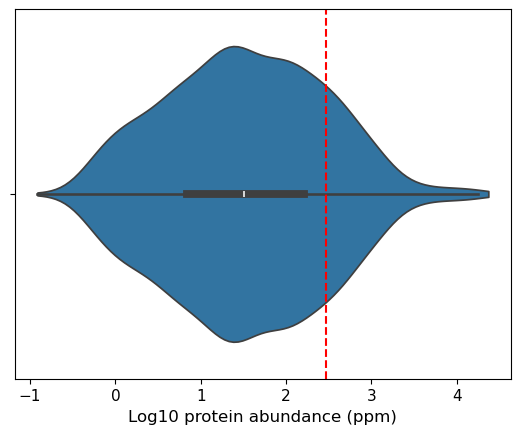

In [11]:
# Comparing FCY1 with all other enzymes
log10_fcy1 = enzymes_abun[enzymes_abun['gene_name'] == 'FCY1']['Log10_abun'].values[0]
abun_fcy1 = enzymes_abun[enzymes_abun['gene_name'] == 'FCY1']['abundance'].values[0]


sns.violinplot(data=enzymes_abun, x='Log10_abun', cut=0)
plt.gca().axvline(x=log10_fcy1, linestyle='--', color='red')
plt.gca().set_xlabel('Log10 protein abundance (ppm)')

fig = plt.gcf()
fig.savefig(f"Supp_figs/FCY1_abun_dist.png", bbox_inches='tight')

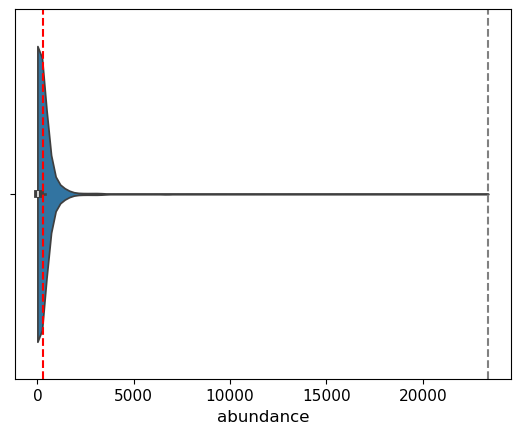

In [12]:
abun_tdh3 = enzymes_abun[enzymes_abun['gene_name'] == 'TDH3']['abundance'].values[0]

sns.violinplot(data=enzymes_abun, x='abundance', cut=0)
plt.gca().axvline(x=abun_fcy1, linestyle='--', color='red')
plt.gca().axvline(x=abun_tdh3, linestyle='--', color='grey')

In [13]:
enzymes_sorted = enzymes_abun.copy().sort_values(by='abundance', na_position='first').reset_index(drop=True)

In [14]:
enzymes_sorted[enzymes_sorted['gene_name'] == 'FCY1']

,gene_name,orf_name,abundance,#,MIRIAM,SHORT NAME,COMPARTMENT,Log10_abun
964,FCY1,YPR062W,293.0,NaN,uniprot/Q12178,FCY1,NaN,2.466868


In [15]:
enzymes_sorted

,gene_name,orf_name,abundance,#,MIRIAM,SHORT NAME,COMPARTMENT,Log10_abun
0,NaN,Q0080,NaN,NaN,uniprot/P00856,ATP8,NaN,NaN
1,NaN,YBR180W,NaN,NaN,uniprot/P38125,DTR1,NaN,NaN
2,NaN,YPL096C-A,NaN,NaN,uniprot/P62651,ERI1,NaN,NaN
3,THI22,YPR121W,0.122,NaN,uniprot/Q06490,THI22,NaN,-0.913640
4,CLD1,YGR110W,0.216,NaN,uniprot/P53264,CLD1,NaN,-0.665546
...,...,...,...,...,...,...,...,...
1156,PDC1,YLR044C,13103.000,NaN,uniprot/P06169,PDC1,NaN,4.117371
1157,PGK1,YCR012W,13748.000,NaN,uniprot/P00560,PGK1,NaN,4.138240
1158,ENO2,YHR174W,16102.000,NaN,uniprot/P00925,ENO2,NaN,4.206880
1159,FBA1,YKL060C,17764.000,NaN,uniprot/P14540,FBA1,NaN,4.249541


In [16]:
fcy1_percentile = (965/1161) * 100
print(f"FCY1 is at the {fcy1_percentile} of enzyme abundance")

FCY1 is at the 83.11800172265289 of enzyme abundance


What fractions of endogenous enzyme abundance levels are found within the DME of mutations in the FCY1 promoter?

In [50]:
min_DME = abun_fcy1*0.130870724
max_DME = abun_fcy1*1.469343278

# obtaining the corresponding percentiles
min_percent = (enzymes_sorted[enzymes_sorted['abundance'] >= min_DME].shape[0] / enzymes_sorted.shape[0]) * 100
max_percent = (enzymes_sorted[enzymes_sorted['abundance'] <= max_DME].shape[0] / enzymes_sorted.shape[0]) * 100

In [52]:
enzymes_sorted[enzymes_sorted['abundance'] >= min_DME].shape[0]

543

In [54]:
enzymes_sorted[enzymes_sorted['abundance'] <= max_DME].shape[0]

1014

In [56]:
min_percent

46.770025839793284

In [58]:
max_percent

87.33850129198967